In [1]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 24.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive


--- Step 1: Loading Data (Expanded Neutral/Anxiety) ---
Loaded Neutral: 5477 samples from Emotion - Neutral_FLEX2_278540_2025.11.24T16.42.23+08.00.md.bp.csv
Loaded Anxiety: 7764 samples from Emotion - Anxiety_FLEX2_278540_2025.11.24T17.19.54+08.00.md.bp.csv
Loaded Sad: 10883 samples from Emotion - Sad 2_FLEX2_278540_2025.11.24T17.09.42+08.00.md.bp.csv
Loaded Happy: 6892 samples from Emotion - Happy_FLEX2_278540_2025.11.24T16.50.07+08.00.md.bp.csv

--- Step 2: Balancing Data ---
Balanced Counts: (array([0, 1, 2, 3]), array([4000, 4000, 4000, 4000]))

--- Step 3: Training SVM ---

--- Step 4: Final Results ---
         Accuracy  Precision  Recall  F1-Score
Emotion                                       
Happy        0.99       0.97    0.99      0.98
Neutral      0.87       0.59    0.91      0.71
Sad          0.85       0.90    0.65      0.76
Anxiety      0.98       0.98    0.95      0.97

Overall Model Accuracy: 0.85


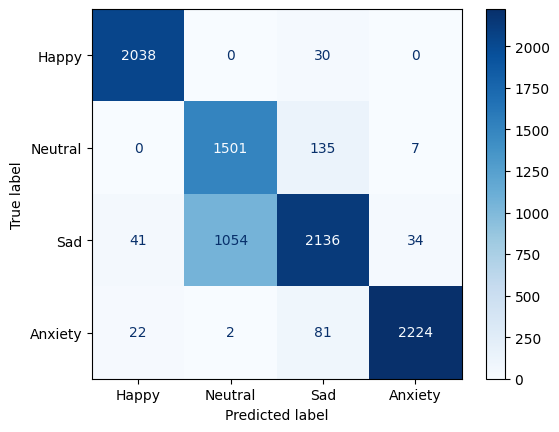

In [61]:
import pandas as pd
import numpy as np
import glob
import os
import warnings
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# ==========================================
# 0. SETUP
# ==========================================
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION
# ==========================================
FOLDER_PATH = '/content/drive/MyDrive/Latest Emotion Data/'
EMOTION_LABELS = {'Happy': 0, 'Neutral': 1, 'Sad': 2, 'Anxiety': 3}
ROLLING_WINDOW_SIZE = 128
FINAL_TARGET_SIZE = 4000

# USEFUL ELECTRODES
TARGET_SENSORS = list(set([
    'F3', 'Fp1', 'AF3', 'FC5',  # Happy
    'F4', 'Fp2', 'AF4', 'FC6',  # Sad
    'F8', 'T7', 'T8',           # Anxiety
    'O1', 'O2', 'Oz', 'Cz',     # Neutral
    'Fp2', 'Fp1', 'F4', 'Fz', 'C4', 'Pz' # Anxiety extras
]))

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def add_ratios_smart(df):
    cols = df.columns
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

    alpha_cols = [c for c in df.columns if "Alpha" in c]
    for alpha_col in alpha_cols:
        beta_col = alpha_col.replace("Alpha", "Beta")
        theta_col = alpha_col.replace("Alpha", "Theta")

        if '.' in alpha_col:
            sensor = alpha_col.split('.')[1]
            if beta_col in df.columns:
                df[f"Ratio.{sensor}.BetaAlpha"] = df[beta_col] / (df[alpha_col] + 1e-6)
            if theta_col in df.columns and beta_col in df.columns:
                df[f"Ratio.{sensor}.ThetaBeta"] = df[theta_col] / (df[beta_col] + 1e-6)

    # Global Frontal-Occipital Ratio (For Neutral Detection)
    frontal_beta = [c for c in df.columns if 'Beta' in c and any(x in c for x in ['F3','F4','Fp1','Fp2'])]
    occipital_alpha = [c for c in df.columns if 'Alpha' in c and any(x in c for x in ['O1','O2','Oz'])]
    if frontal_beta and occipital_alpha:
        df['Ratio.Global.FrontalOccipital'] = df[frontal_beta].sum(axis=1) / (df[occipital_alpha].sum(axis=1) + 1e-6)

    return df

def parse_intervals(marker_file, mode='ALL', target_index=None):
    if not os.path.exists(marker_file): return None
    try:
        df_m = pd.read_csv(marker_file, header=0)
        if not any('timestamp' in c.lower() for c in df_m.columns):
            df_m = pd.read_csv(marker_file, header=1)
    except: return None

    df_m.columns = [c.lower() for c in df_m.columns]
    ts_col = next((c for c in df_m.columns if 'timestamp' in c), None)
    type_col = next((c for c in df_m.columns if 'type' in c), None)
    if not ts_col: return None

    valid_intervals = []
    starts, ends = [], []
    if type_col:
        for i, row in df_m.iterrows():
            evt = str(row[type_col])
            val = row[ts_col]
            if 'Start' in evt: starts.append(val)
            elif 'End' in evt: ends.append(val)
        count = min(len(starts), len(ends))
        for i in range(count):
            if starts[i] < ends[i]: valid_intervals.append((starts[i], ends[i]))

    if mode == 'SELECT' and target_index is not None:
        if len(valid_intervals) > target_index: return [valid_intervals[target_index]]
        else: return valid_intervals
    return valid_intervals

# ==========================================
# 3. MAIN PIPELINE
# ==========================================
print(f"--- Step 1: Loading Data (Expanded Neutral/Anxiety) ---")

X_all_list = []
y_all_list = []
loaded_files = set()

data_files = glob.glob(os.path.join(FOLDER_PATH, "*md.bp.csv"))

for data_file in data_files:
    filename = os.path.basename(data_file)
    if filename in loaded_files: continue

    process_file = False
    label_name = None
    mode = 'ALL'
    target_idx = None

    # 1. HAPPY
    if "Happy" in filename:
        label_name = "Happy"
        mode = 'ALL'
        process_file = True

    # 2. NEUTRAL
    elif "Neutral" in filename:
        label_name = "Neutral"
        mode = 'ALL'
        process_file = True

    # 3. SAD
    elif "Sad" in filename:
        if "Sad 2" in filename:
            label_name = "Sad"
            mode = 'ALL'
            process_file = True
        else:
            continue

    # 4. ANXIETY
    elif "Anxiety" in filename:
        if "Anxiety 2" in filename:
            continue
        else:
            label_name = "Anxiety"
            mode = 'ALL'
            process_file = True

    if not process_file: continue

    # Load
    try: df = pd.read_csv(data_file, header=1)
    except: continue

    marker_file = data_file.replace('.md.bp.csv', '_intervalMarker.csv')
    if not os.path.exists(marker_file): marker_file = data_file.replace('.csv', '_intervalMarker.csv')

    intervals = parse_intervals(marker_file, mode, target_idx)
    df_combined = pd.DataFrame()
    time_col = next((c for c in df.columns if 'timestamp' in c.lower()), None)

    if intervals and time_col:
        for (start, end) in intervals:
            chunk = df[(df[time_col] >= start) & (df[time_col] <= end)]
            df_combined = pd.concat([df_combined, chunk])
    else:
        if mode == 'ALL': df_combined = df

    if len(df_combined) < 50: continue

    # Feature Engineering
    df_combined = add_ratios_smart(df_combined)

    keep_cols = []
    for col in df_combined.columns:
        if "Ratio.Global" in col:
            keep_cols.append(col)
            continue
        if not ("Pow" in col or "EEG" in col or "Ratio" in col): continue
        if any(bad in col for bad in ['Counter', 'Battery', 'Clock', 'Interpolated', 'Quality', 'BufferSize']): continue

        # Check against TARGET_SENSORS
        parts = col.split('.')
        if len(parts) > 1 and parts[1] in TARGET_SENSORS:
            keep_cols.append(col)

    if not keep_cols: continue

    df_features = df_combined[keep_cols]
    df_smooth = df_features.rolling(window=ROLLING_WINDOW_SIZE).mean().dropna()
    data = df_smooth.values

    if len(data) == 0: continue

    X_all_list.append(data)
    y_all_list.append(np.full(len(data), EMOTION_LABELS[label_name]))
    loaded_files.add(filename)

    print(f"Loaded {label_name}: {len(data)} samples from {filename}")

# --- MERGE & SPLIT ---
if not X_all_list:
    print("Error: No data found. Check folder path.")
else:
    X = np.vstack(X_all_list)
    y = np.concatenate(y_all_list)

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ==========================================
    # 4. BALANCING
    # ==========================================
    print("\n--- Step 2: Balancing Data ---")
    counts = dict(zip(*np.unique(y_train, return_counts=True)))
    safe_under = {k: min(v, FINAL_TARGET_SIZE) for k,v in counts.items()}

    pipeline = Pipeline([
        ('under', RandomUnderSampler(sampling_strategy=safe_under, random_state=42)),
        ('over', SMOTE(sampling_strategy='all', random_state=42))
    ])

    X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train_scaled, y_train)
    print("Balanced Counts:", np.unique(y_train_balanced, return_counts=True))

    # --- TRAIN ---
    print("\n--- Step 3: Training SVM ---")
    svm_model = SVC(kernel='rbf', C=10, gamma='scale')
    svm_model.fit(X_train_balanced, y_train_balanced)

    # --- OUTPUT TABLE ---
    print("\n--- Step 4: Final Results ---")
    y_pred = svm_model.predict(X_test_scaled)

    results_data = []
    from sklearn.metrics import precision_score, recall_score, f1_score

    present_labels = sorted(list(set(y_test) | set(y_pred)))

    for label_idx in present_labels:
        label_name = [k for k, v in EMOTION_LABELS.items() if v == label_idx][0]

        TP = np.sum((y_test == label_idx) & (y_pred == label_idx))
        TN = np.sum((y_test != label_idx) & (y_pred != label_idx))
        FP = np.sum((y_test != label_idx) & (y_pred == label_idx))
        FN = np.sum((y_test == label_idx) & (y_pred != label_idx))

        accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN)>0 else 0
        precision = precision_score(y_test, y_pred, labels=[label_idx], average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, labels=[label_idx], average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, labels=[label_idx], average='macro', zero_division=0)

        results_data.append({
            "Emotion": label_name,
            "Accuracy": round(accuracy, 2),
            "Precision": round(precision, 2),
            "Recall": round(recall, 2),
            "F1-Score": round(f1, 2)
        })

    results_df = pd.DataFrame(results_data).set_index("Emotion")
    results_df = results_df[["Accuracy", "Precision", "Recall", "F1-Score"]]
    print(results_df)

    print(f"\nOverall Model Accuracy: {np.mean(y_pred == y_test):.2f}")

    cm = confusion_matrix(y_test, y_pred)
    display_labels = [k for k, v in EMOTION_LABELS.items() if v in present_labels]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

In [62]:
import joblib
from google.colab import files

print("Saving model...")
# Save the trained SVM model
joblib.dump(svm_model, 'emotion_svm_model.pkl')

print("Downloading to your computer...")
files.download('emotion_svm_model.pkl')

Saving model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>